In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

In [3]:
Ni_K = pd.read_csv('ref_Ni_K_XAFS.csv', sep=',', usecols=['energy', 'IT_cps_ave', 'I0_cps_ave'])
Ni_K['absorbance'] = -1 * np.log(Ni_K['IT_cps_ave']/Ni_K['I0_cps_ave'])
Ni_K.head()

,energy,IT_cps_ave,I0_cps_ave,absorbance
0,8208.0,144074.666584,195549.934306,0.305484
1,8210.5,143755.579750,194935.183326,0.304553
2,8213.0,142060.603724,193117.326379,0.307044
3,8215.5,144227.089134,195520.484793,0.304276
4,8218.0,144260.903057,195915.643960,0.306061


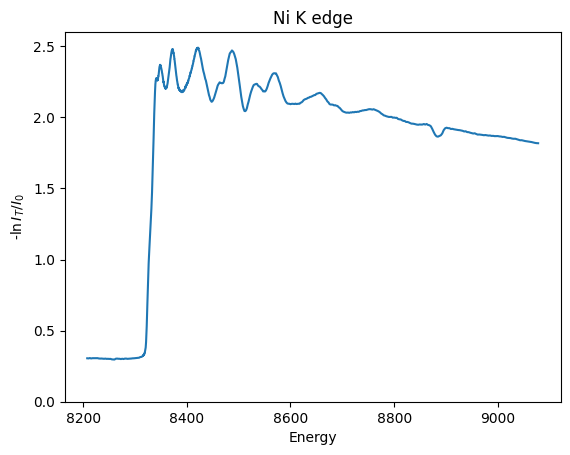

In [23]:
plt.plot(Ni_K['energy'], Ni_K['absorbance'])
plt.title('Ni K edge')
plt.xlabel('Energy')
plt.ylabel(r'-$\ln I_T/I_0$')
plt.ylim(bottom=0)
plt.show()

In [20]:
raw_edge_step = 2.0826687
Ni_K['edge step 0.5'] = Ni_K['absorbance'] * (0.5 / raw_edge_step)
Ni_K['edge step 1'] = Ni_K['absorbance'] * (1 / raw_edge_step)
Ni_K['edge step 2'] = Ni_K['absorbance'] * (2 / raw_edge_step)
Ni_K['edge step 3'] = Ni_K['absorbance'] * (3 / raw_edge_step)
Ni_K.head()

,energy,IT_cps_ave,I0_cps_ave,absorbance,edge step 0.5,edge step 1,edge step 2,edge step 3
0,8208.0,144074.666584,195549.934306,0.305484,0.073340,0.146679,0.293358,0.440037
1,8210.5,143755.579750,194935.183326,0.304553,0.073116,0.146232,0.292464,0.438696
2,8213.0,142060.603724,193117.326379,0.307044,0.073714,0.147428,0.294856,0.442285
3,8215.5,144227.089134,195520.484793,0.304276,0.073050,0.146099,0.292198,0.438297
4,8218.0,144260.903057,195915.643960,0.306061,0.073478,0.146956,0.293912,0.440868


In [9]:
def frac_IT(mu_t, x : float):
    return x * np.exp(-1 * mu_t / x) + (1 - x)

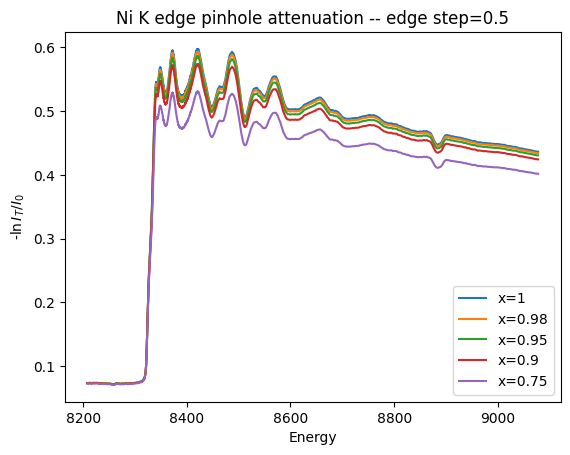

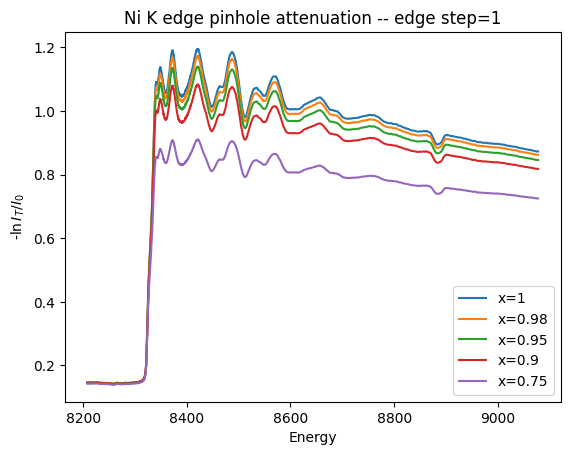

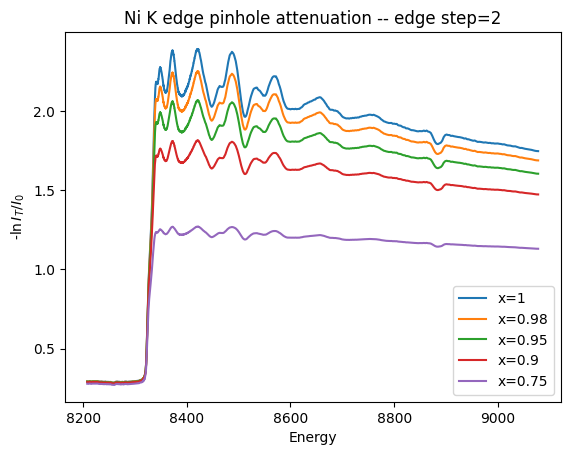

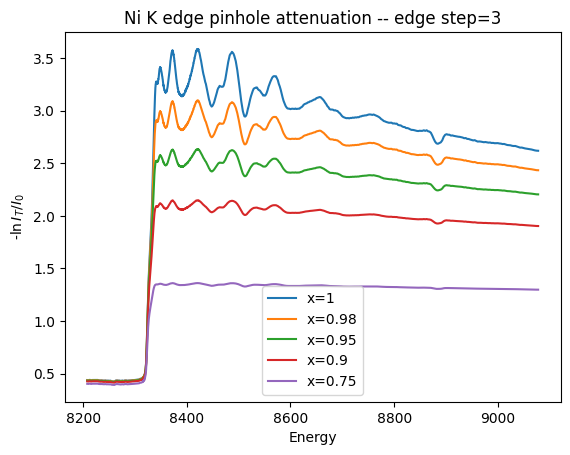

In [22]:
I_0 = Ni_K['I0_cps_ave']

for step in (0.5, 1, 2, 3):
    mu_t = Ni_K[f'edge step {step}']
    plt.title(f'Ni K edge pinhole attenuation -- edge step={step}')
    plt.xlabel('Energy')
    plt.ylabel(r'-$\ln I_T/I_0$')
    plt.plot(Ni_K['energy'], Ni_K[f'edge step {step}'], label='x=1')
    for x in (0.98, 0.95, 0.9, 0.75):
        plt.plot(Ni_K['energy'], -1 * np.log(frac_IT(mu_t, x)), label=f'x={x}')
    plt.legend()
    plt.show()

In [27]:
for step in (0.5, 1, 2, 3):
    filename = f'{step}_Ni_K_XAFS'
    abs = f'edge step {step}'
    Ni_K.to_csv(filename, sep=',', columns=['energy', abs])